In [5]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi

In [90]:
def hl2_prime(n, z):
    return (n / z) * hankel2(n, z) - hankel2(n + 1, z) # derivative for hankel function of second kind
def hl1_prime(n, z):
    return (n / z) * hankel1(n, z) - hankel1(n + 1, z) # derivative for hankel function of first kind
def hl1_asymptotic(n, z):
    #return sqrt(2/(pi*z))*np.exp(1j*(z-pi/4))*(-1j)**n
    return sqrt(1/(pi*z))*(1-1j)*np.exp(1j*z)*(-1j)**n
def hl2_asymptotic(n, z):
    return np.conj(hl1_asymptotic(n, z))

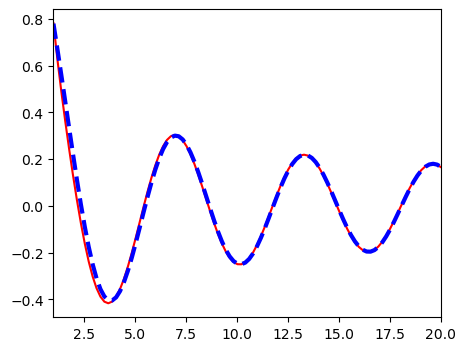

In [91]:
x = linspace(1, 20, 100, endpoint=True)
hankel_exact = hankel2(1, x)
hankel_approximate = hl2_asymptotic(1, x)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, hankel_exact.imag, color="red")
ax.plot(x, hankel_approximate.imag, linestyle="dashed", linewidth=3, color="blue")
ax.set_xlim(1, 20);

### Coherent perfect absorption through finite surface impedance 

In [145]:
M = 1000
epsilon = 1
l = 0
Z_s = -1 ## Impedance of the surface layer in units of 1/c*epsilon_0
x = np.linspace(1, 20, M) # Free space kR
y = x * sqrt(epsilon) # epsilonkR in the cylinder
lhs_num = sqrt(epsilon) * jv(l, y) * hl2_prime(l, x)
rhs_num =  jvp(l, y, 1) * hankel2(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl2_prime(l, x)

lhs_denom =  jvp(l, y, 1) * hankel1(l, x) + 1j*(1/Z_s)*jvp(l, y, 1)*hl1_prime(l, x)
rhs_denom = sqrt(epsilon) * jv(l, y) * hl1_prime(l, x)

s = (lhs_num-rhs_num)/(lhs_denom-rhs_denom)

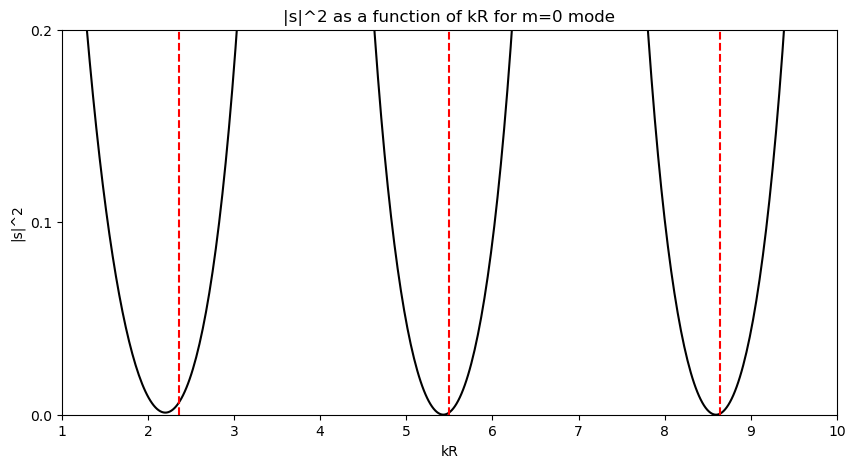

In [151]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(x, np.abs(s)**2, linestyle="solid", color="black")
plt.ylim(0, 0.2)
plt.vlines([-pi/4]+np.pi *np.linspace(1, 30, 30), 0, 1, color="red", linestyle="dashed")
ax.set_xlim(1, 10)
plt.xlabel("kR")
plt.ylabel("|s|^2");
ax.set_title("|s|^2 as a function of kR for m=0 mode");
ax.set_yticks([0, 0.1, 0.2]);